In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Src.data import load_csv_df
from Src.plotting import set_plotting_style

In [2]:
set_plotting_style()

In [3]:
DF_PATH = "../Data/Raw/raw-data.csv"

# Safely loading dataframe using function from mine Src module (data)
df = load_csv_df(
    df_path=DF_PATH,
)

Successfully loaded dataframe: ..\Data\Raw\raw-data.csv
Dataframe has: 8950 rows / 18 columns
Dataframe size: 0.861MB


In [4]:
df_dtypes = df.dtypes.to_frame("Dtype").reset_index(names="Column")
display(df_dtypes)

,Column,Dtype
0,CUST_ID,str
1,BALANCE,float64
2,BALANCE_FREQUENCY,float64
3,PURCHASES,float64
4,ONEOFF_PURCHASES,float64
5,INSTALLMENTS_PURCHASES,float64
6,CASH_ADVANCE,float64
7,PURCHASES_FREQUENCY,float64
8,ONEOFF_PURCHASES_FREQUENCY,float64
9,PURCHASES_INSTALLMENTS_FREQUENCY,float64


In [5]:
CATEGORIAL_COL = df.select_dtypes(include=["object", "string", "category"]).columns
NUMERIC_COL = df.select_dtypes(exclude=["object", "string", "category"]).columns

print(f"Dataframe contains:")
print(f"- {len(CATEGORIAL_COL)} categorical columns")
print(f"- {len(NUMERIC_COL)} numeric columns")
# Dataframe has 17 numeric columns and only 1 categorial.

Dataframe contains:
- 1 categorical columns
- 17 numeric columns


In [6]:
display(df.head(3))
display(df.tail(3))

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.0,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
8947,C19188,23.398673,0.833333,144.40,0.00,144.4,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.0,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.0,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [7]:
cust_id_values = df["CUST_ID"].unique()
print(f"CustomerID values count: {len(cust_id_values)} / {df.shape[0]} (Whole df)")

# CUST_ID has exact same unique value amount (8950) as whole dataframe rows
# so it no use
df = df.drop(columns=["CUST_ID"])
print(f"Dataframe has: {df.shape[0]} rows / {df.shape[1]} columns")

CustomerID values count: 8950 / 8950 (Whole df)
Dataframe has: 8950 rows / 17 columns


In [8]:
MISSING = df.isna().sum()
print(f"Dataframe has: {MISSING} missing values")
# Dataframe has 1 missing in CREDIT_LIMIT and 313 in MINIMUM_PAYMENTS

Dataframe has: BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64 missing values


In [9]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df.median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df.median())

In [10]:
DUPLICATES = df.duplicated().sum()
print(f"Dataframe has: {DUPLICATES} duplicated values")
# Dataframe doesn't have any duplicates

Dataframe has: 0 duplicated values


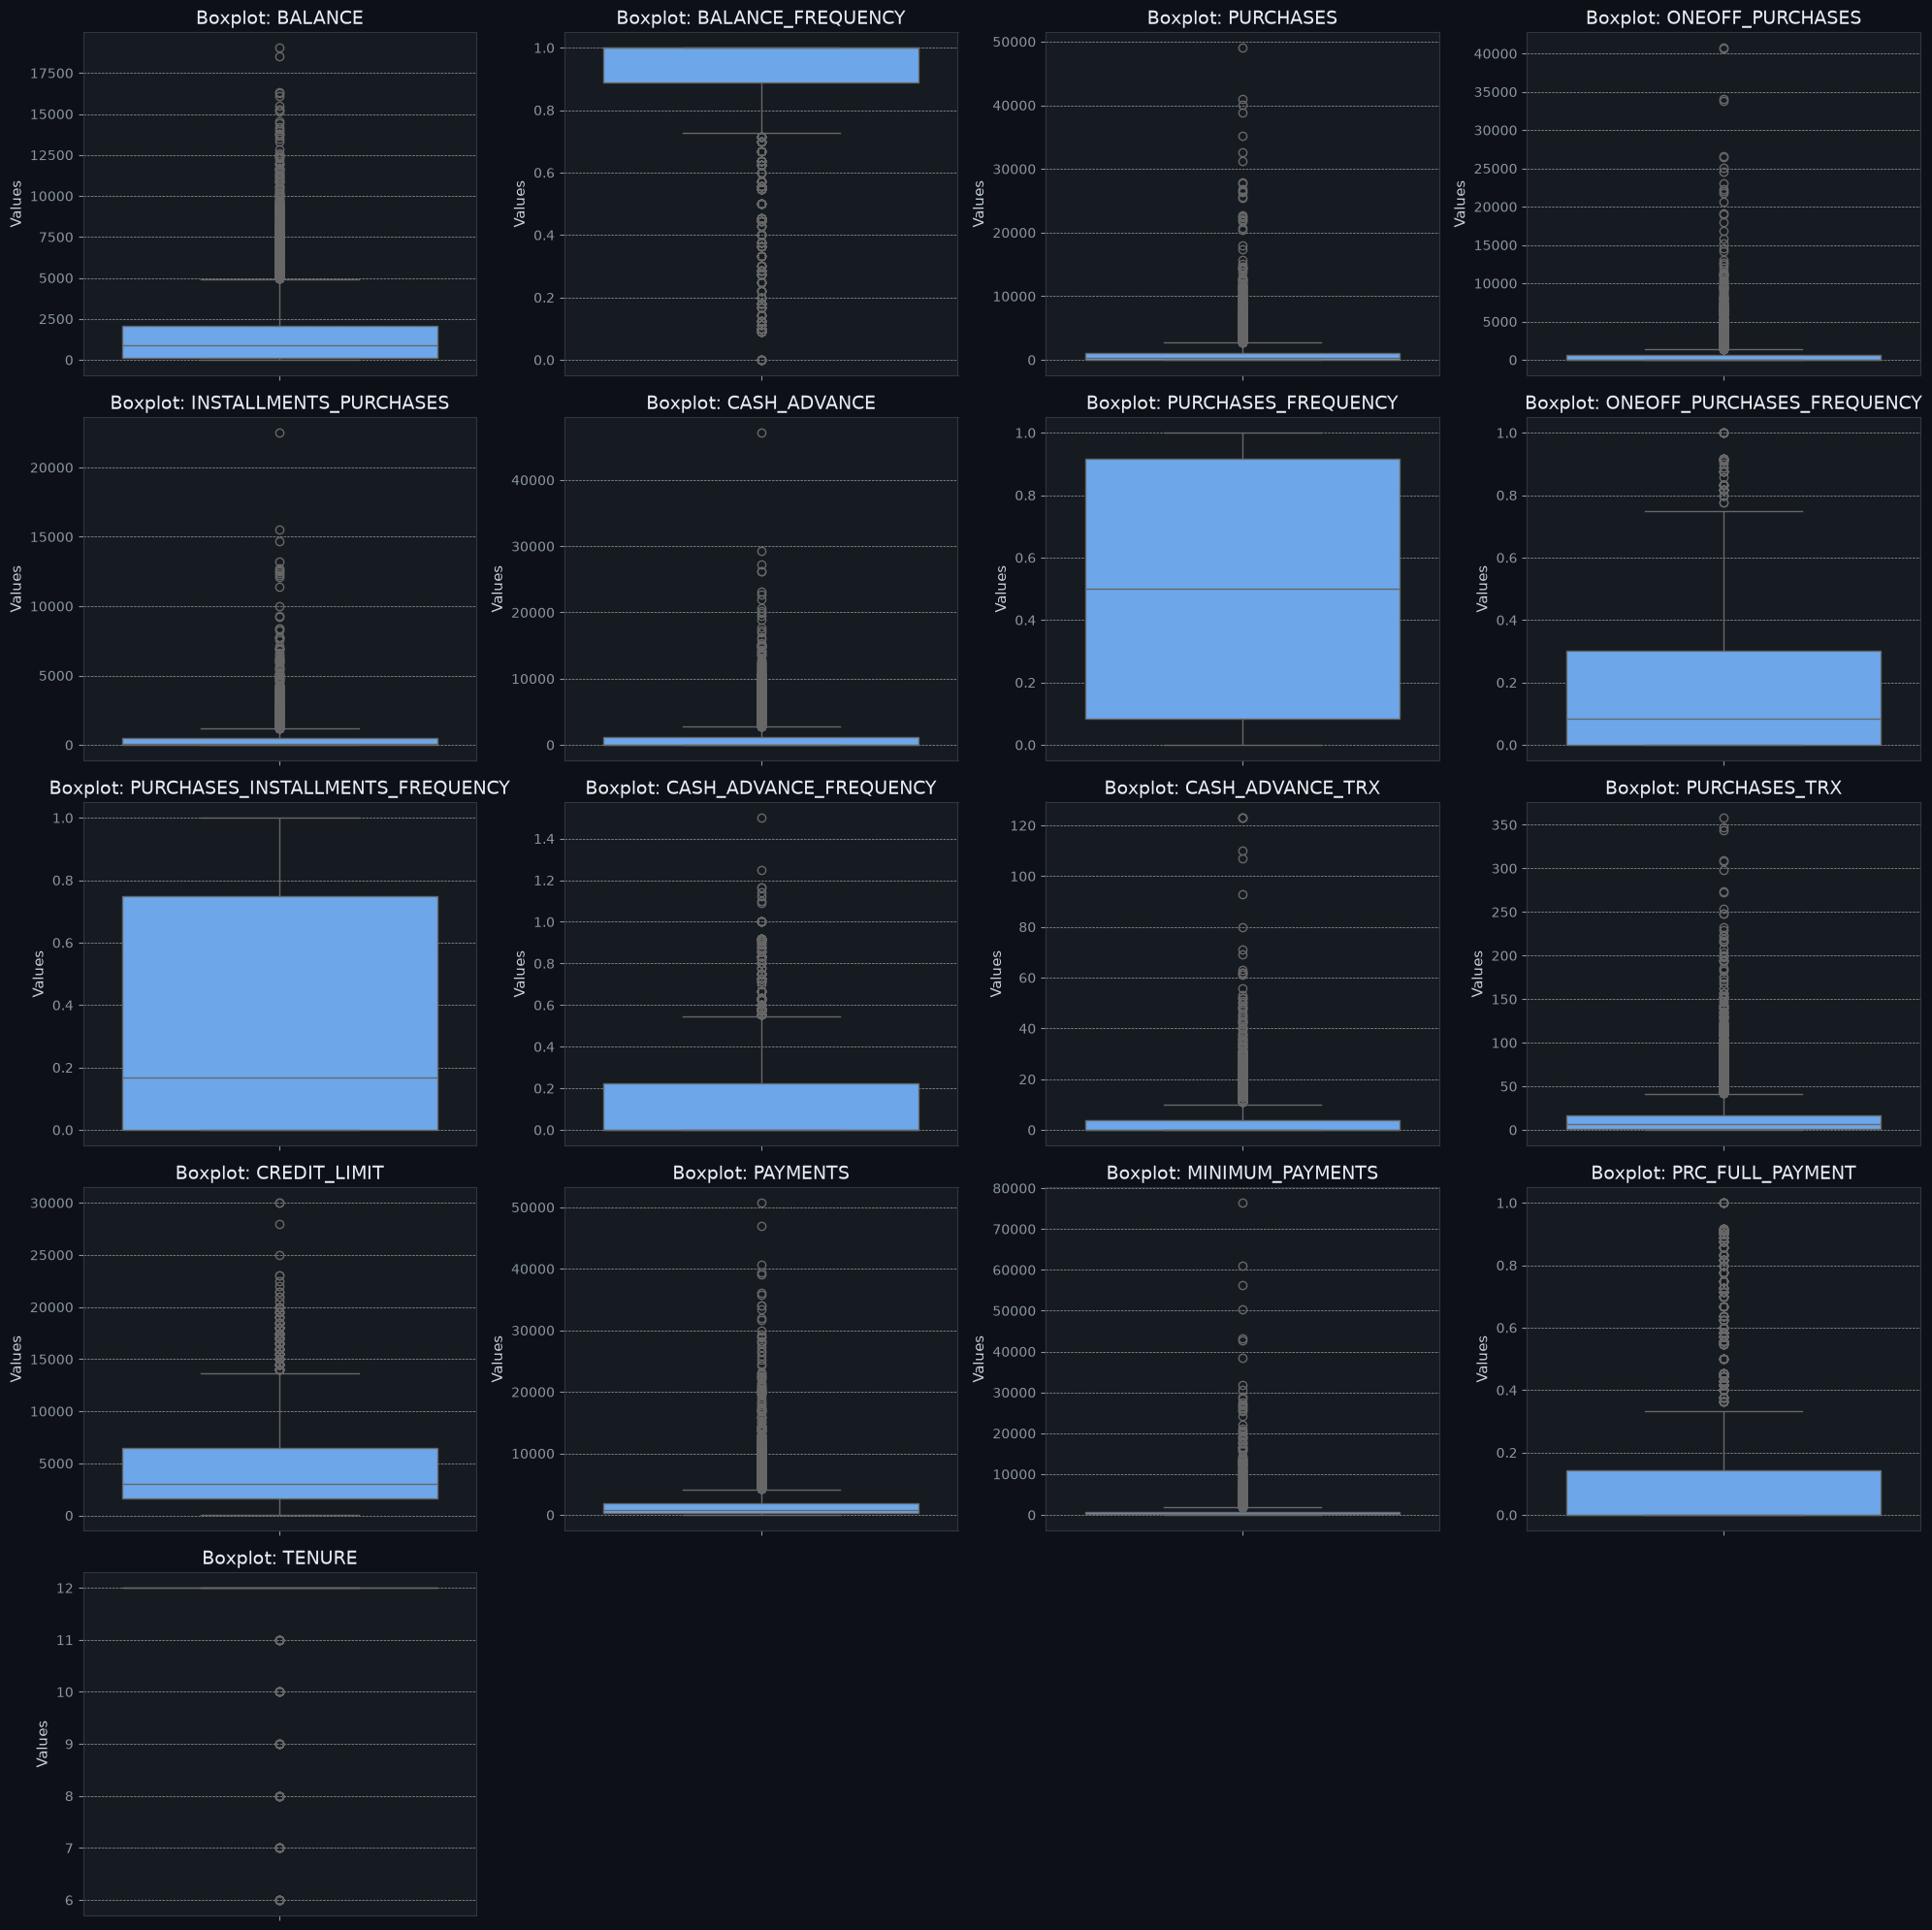

In [11]:
n_cols = 4
n_rows = (len(NUMERIC_COL) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COL):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_ylabel("Values")

for i in range(len(NUMERIC_COL), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""
All numeric columns have outliers and must be log
except TENURE which is categorial (6-12 values) and stays the same
"""